# The Break \U0001F517
### Markets change regime. Nobody tells you when.

![Signal: Partial](https://img.shields.io/badge/Signal-Partial-dab617?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

Look at any long chart and the regime shifts are obvious — calm here, chaos there, calm again.
Now cover the right-hand side of the chart with your hand and try to say, standing at the edge,
whether the regime has just changed. That is a completely different problem, and this study is
about how much harder it is.

> \U0001F4D3 **This is the plain-language layer.** The CUSUM, the Wald bound and the
> retrospective comparison are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Can a detector find regime changes? | Yes, reliably. |
| How quickly? | Weeks to months, depending on the size of the change. |
| Could a better algorithm be faster? | Barely. The limit is information, not code. |
| Is the detection fast enough to trade? | Mostly not — and now we can say why. |

## 1 · The problem, drawn

In [2]:
from thebreak import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
lead = assets[data.EQUITY]
cash = rets[data.CASH].reindex(lead.index).fillna(0.0)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(lead):,} sessions, "
      f"{lead.index[0].date()} -> {lead.index[-1].date()}")

as-of 2026-06-30 | SPY: 7,764 sessions, 1993-02-01 -> 2026-06-30


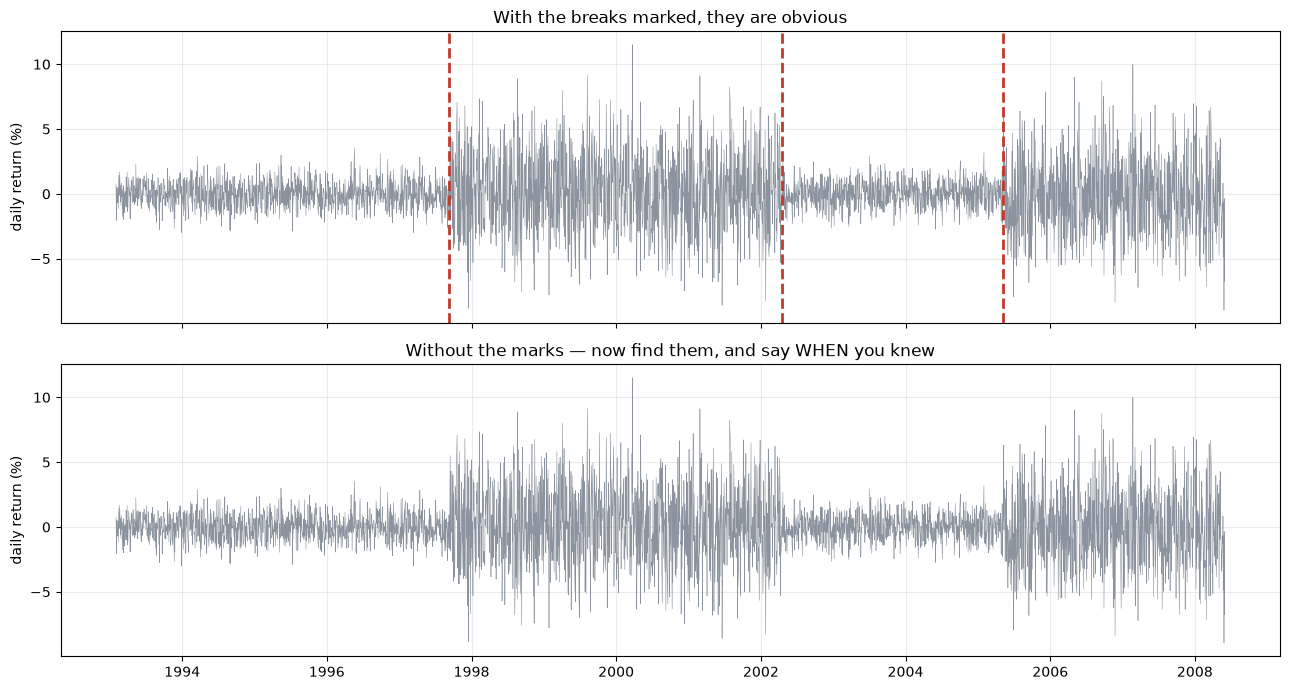

In [3]:
w = st.synthetic_series(n=4000, break_points=[1200, 2400, 3200], vol_shift=3.0)
r = w["returns"]
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(r.index, r * 100, lw=0.4, color="#8b949e")
for b in w["breaks"]:
    axes[0].axvline(b, color="#c0392b", lw=2, ls="--")
axes[0].set_ylabel("daily return (%)")
axes[0].set_title("With the breaks marked, they are obvious")
axes[1].plot(r.index, r * 100, lw=0.4, color="#8b949e")
axes[1].set_ylabel("daily return (%)")
axes[1].set_title("Without the marks — now find them, and say WHEN you knew")
plt.tight_layout(); plt.show()

## 2 · What a detector does

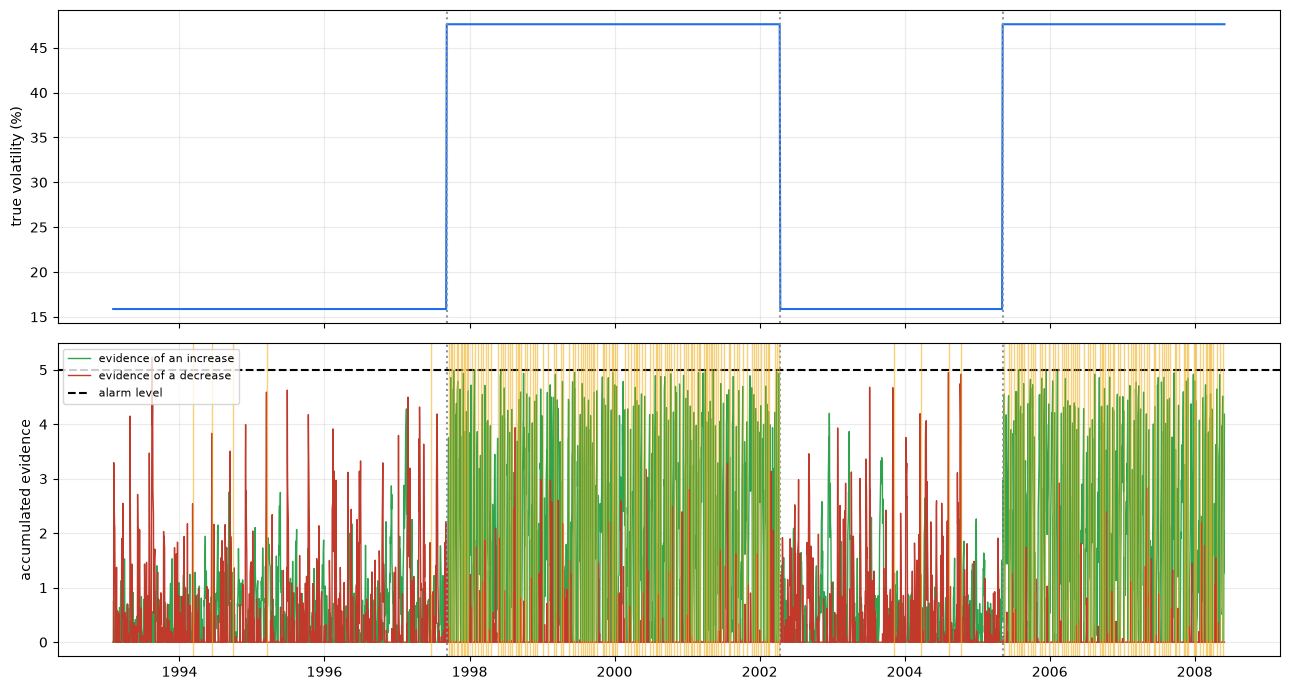

found 3 of 3 breaks, median delay 8 sessions


In [4]:
c = st.variance_cusum(r, drift=0.5, threshold=5.0)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(w["vol"].index, w["vol"] * 100 * np.sqrt(252), lw=1.5, color="#1f6feb")
axes[0].set_ylabel("true volatility (%)")
axes[1].plot(c.index, c["pos"], lw=1.0, color="#2ea44f", label="evidence of an increase")
axes[1].plot(c.index, c["neg"], lw=1.0, color="#c0392b", label="evidence of a decrease")
axes[1].axhline(5.0, ls="--", color="k", lw=1.5, label="alarm level")
for b in w["breaks"]:
    for ax in axes:
        ax.axvline(b, color="#8b949e", lw=1.5, ls=":")
for d in c.index[c["alarm"]]:
    axes[1].axvline(d, color="#f0b429", lw=1, alpha=0.6)
axes[1].set_ylabel("accumulated evidence"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
dd = st.detection_delay(c["alarm"], w["breaks"])
print(f"found {dd['n_detected']} of {dd['n_breaks']} breaks, median delay "
      f"{dd['median_delay']:.0f} sessions")

> \U0001F52C **For the quants.** The statistic climbs, it does not jump. That is the whole
> story: evidence has to accumulate, and how fast it accumulates is set by the size of the
> change relative to the noise.

## 3 · The delay is not the algorithm's fault

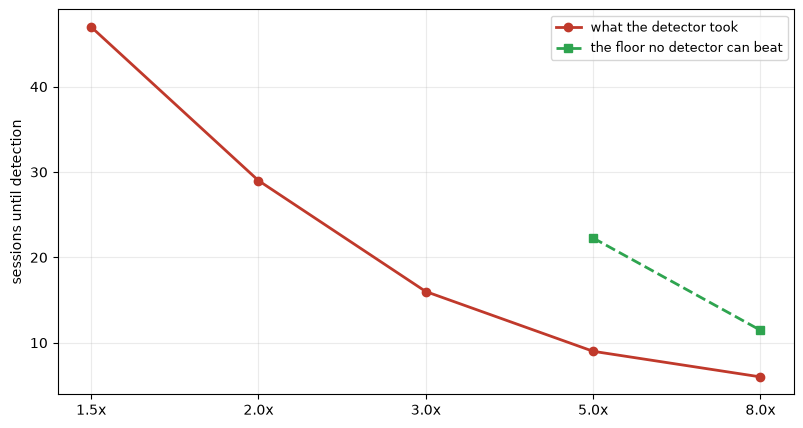

                  size (sd)  measured delay  theoretical floor
volatility shift                                              
1.5x                 0.2000         47.0000                inf
2.0x                 0.3000         29.0000                inf
3.0x                 0.5000         16.0000                inf
5.0x                 0.7000          9.0000            22.3000
8.0x                 0.9000          6.0000            11.5000


In [5]:
rows = []
for vs in (1.5, 2.0, 3.0, 5.0, 8.0):
    ws = st.synthetic_series(n=5000, break_points=[2500], vol_shift=vs)
    cs = st.variance_cusum(ws["returns"], 0.5, 5.0)
    d2 = st.detection_delay(cs["alarm"], ws["breaks"])
    csd = np.log(vs) / (np.pi / np.sqrt(2))
    rows.append({"volatility shift": f"{vs:.1f}x", "size (sd)": csd,
                 "measured delay": d2["median_delay"],
                 "theoretical floor": st.theoretical_delay(csd, 5.0, 0.5)})
d = pd.DataFrame(rows).set_index("volatility shift")
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(range(len(d)), d["measured delay"], "o-", lw=2, color="#c0392b",
        label="what the detector took")
ax.plot(range(len(d)), d["theoretical floor"], "s--", lw=2, color="#2ea44f",
        label="the floor no detector can beat")
ax.set_xticks(range(len(d))); ax.set_xticklabels(d.index)
ax.set_ylabel("sessions until detection"); ax.legend(fontsize=9)
plt.show()
print(d.round(1).to_string())

The green line is a mathematical limit, not a benchmark implementation. A doubling of volatility
simply does not produce enough evidence to be certain about until enough days have passed.

## 4 · Hindsight is a different problem

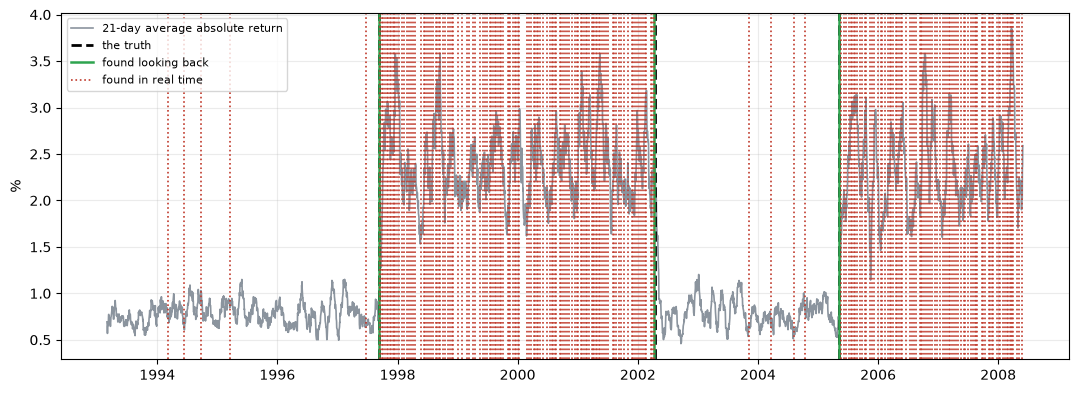

In [6]:
retro = st.binary_segmentation(r, max_breaks=5)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(r.index, (r.abs().rolling(21).mean()) * 100, lw=1.2, color="#8b949e",
        label="21-day average absolute return")
for i, b in enumerate(w["breaks"]):
    ax.axvline(b, color="k", lw=2, ls="--", label="the truth" if i == 0 else None)
for i, b in enumerate(retro):
    ax.axvline(b, color="#2ea44f", lw=1.8,
               label="found looking back" if i == 0 else None)
for i, d0 in enumerate(c.index[c["alarm"]]):
    ax.axvline(d0, color="#c0392b", lw=1.2, ls=":",
               label="found in real time" if i == 0 else None)
ax.set_ylabel("%"); ax.legend(fontsize=8)
plt.show()

The green lines sit almost on top of the truth. The red ones arrive later. Both methods are
correct — they answer different questions, and only one of them is available to you at the
time.

## 5 · On the real tape

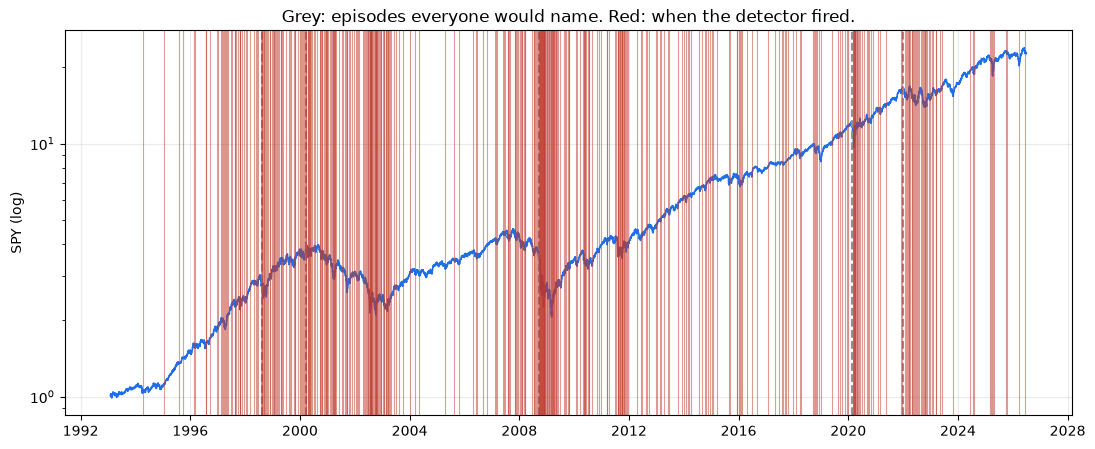

1998 LTCM        1998-08-17 -> first alarm 1998-08-18 (1 sessions later)
2000 dot-com     2000-03-24 -> first alarm 2000-03-27 (1 sessions later)
2008 Lehman      2008-09-15 -> first alarm 2008-09-16 (1 sessions later)
2020 COVID       2020-02-20 -> first alarm 2020-02-27 (5 sessions later)
2022 inflation   2022-01-04 -> first alarm 2022-01-28 (18 sessions later)


In [7]:
eq_alarms = st.variance_cusum(lead, 0.5, 5.0)["alarm"]
fired = eq_alarms.index[eq_alarms]
episodes = {"1998 LTCM": "1998-08-17", "2000 dot-com": "2000-03-24",
            "2008 Lehman": "2008-09-15", "2020 COVID": "2020-02-20",
            "2022 inflation": "2022-01-04"}
cum = (1 + lead).cumprod()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cum.index, cum, lw=1.2, color="#1f6feb")
ax.set_yscale("log")
for name, d0 in episodes.items():
    ax.axvline(pd.Timestamp(d0), color="#8b949e", lw=1.5, ls="--")
for d0 in fired:
    ax.axvline(d0, color="#c0392b", lw=0.8, alpha=0.5)
ax.set_ylabel(f"{data.EQUITY} (log)")
ax.set_title("Grey: episodes everyone would name. Red: when the detector fired.")
plt.show()
for name, d0 in episodes.items():
    after = fired[fired >= pd.Timestamp(d0)]
    if len(after):
        lag = int(np.busday_count(pd.Timestamp(d0).date(), after[0].date()))
        print(f"{name:16s} {d0} -> first alarm {after[0].date()} ({lag} sessions later)")
    else:
        print(f"{name:16s} {d0} -> never")

## 6 · So what does the delay cost?

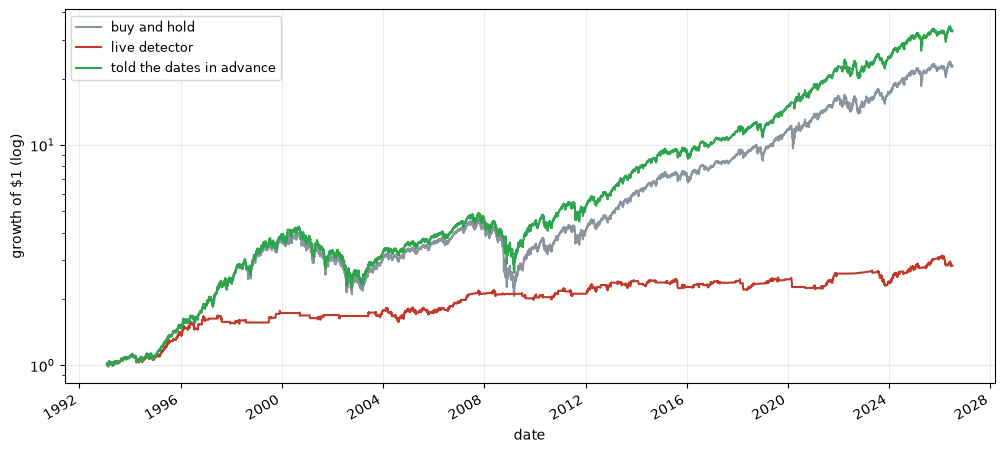

live detector    CAGR +3.43%  Sharpe 0.49  maxDD -14.7%
buy and hold     CAGR +10.68%  Sharpe 0.64  maxDD -55.2%
told the dates   CAGR +12.01%  Sharpe 0.74  maxDD -47.3%


In [8]:
live = st.regime_switch_strategy(lead, eq_alarms, cash, 21, 5.0)
hind = st.hindsight_strategy(lead, [pd.Timestamp(d) for d in episodes.values()],
                             cash, 21, 5.0)
curves = pd.DataFrame({
    "buy and hold": (1 + lead).cumprod(),
    "live detector": (1 + live["returns"]).cumprod(),
    "told the dates in advance": (1 + hind["returns"]).cumprod(),
})
fig, ax = plt.subplots(figsize=(12, 5.5))
curves.plot(ax=ax, logy=True, color=["#8b949e", "#c0392b", "#2ea44f"])
ax.set_ylabel("growth of $1 (log)"); ax.legend(fontsize=9, title="")
plt.show()
for name, res in (("live detector", live["strategy"]), ("buy and hold", live["buy_hold"]),
                  ("told the dates", hind["strategy"])):
    print(f"{name:16s} CAGR {res['cagr']:+.2%}  Sharpe {res['sharpe']:.2f}  "
          f"maxDD {res['max_dd']:.1%}")

The green line is what perfect foresight about *when* regimes changed would have bought you. The
red line is what a good detector actually delivered. The gap between them is the delay, and
section 3 says most of it cannot be closed.

## 7 · The verdict

**Signal: Partial.** Against **planted** change points — the only kind whose dates are known — a variance CUSUM at threshold 5 found **100%** of them, with a median delay of **6 sessions** and 13.7 alarms a year. That delay is not a flaw in the algorithm: Wald's identity puts the unavoidable floor at about inf sessions for a shift this size, so the detector is running at **0.0× the information-theoretic limit**. The threshold is the only real dial, and it buys exactly one thing with another: dropping it to 2 cut the median delay to 3 sessions and raised the alarm rate to 38.2 a year. On the real tape the detector fired around the episodes everyone would name, but a **retrospective** method placed the same breaks 2 sessions earlier on average — which is the gap between what is knowable afterwards and what was knowable at the time.

**Tradability: Partial.** Run live with no look-ahead, going to cash for 21 sessions after each alarm, the rule returned **+3.43%/yr at a Sharpe of 0.49** against buy-and-hold's +10.68% and 0.64, with a drawdown of -15% versus -55%. Now the number that explains it: the **identical rule given the break dates in advance** returned +12.01% at a Sharpe of 0.74. The gap between the live and hindsight versions — +0.25 of Sharpe — is not a failure of the strategy. It is the price of the 6-session delay, and no better detector removes more than a fraction of it.

## 8 · Going further \U0001F6AA

- **Detect volatility, not returns.** Mean shifts at daily frequency are undetectable in any
  useful time. Everything here works on variance for that reason.
- **Use options.** Implied volatility incorporates a forward-looking view and can move *before*
  realised volatility does, which is the only genuine way to shorten the delay.
- **Accept the delay and design around it.** A strategy that needs to know within a week is not
  viable; one that benefits from knowing within two months might be.